# 04: Cost-sensitive learning, and whether it helps

Notebook 03 fitted the unweighted model (configs **A**, **B**, **C**). This adds the three cost-sensitive variants and tests the central hypothesis.

| variant | configs | level (proposal section 3.3) |
|---|---|---|
| weighted | **D** `t=0.5`, **E** NER-optimal | algorithm |
| instance_weighted | **F** | algorithm, per-instance severity |
| rus | **G** | data |

All three derive from the same severity ratio `R = 773.70`: weight `= R`, undersample to `N_neg/R`, threshold `λ = 1/(1+R)`. That is what turns the proposal's three-level taxonomy from a literature structure into a single controlled experiment.

## The pre-registered hypothesis

**H1**: configs **C** and **E** will not differ significantly in PR-AUC from **A**, and **D** will score *lower* than **A**.

This is not a guess. Johnson & Khoshgoftaar (2022) found exactly this on Medicare claims at 0.046% prevalence: *"the best model performance is consistently obtained when RUS and class weighting are **not** applied."* Their explanation is mechanical: weighting shifts probability estimates toward 0.5 without adding discrimination, relocating the operating point rather than improving the ranking. They asked for replication on other severely imbalanced data. This is that replication.

If H1 holds, the finding is that **thresholding, not weighting, is what delivers cost-sensitive fraud detection**  which answers RQ 2.1.3 directly, and is a result rather than a null.

Config **F** is the novel arm: Aleksandrova & Armianova applied case-based severity when choosing a *threshold* and named applying it during *training* as future work. Nobody has done it on mobile money.

In [1]:
import json, sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from momo_fraud import constants as C
from momo_fraud import data as D
from momo_fraud import evaluate as E
from momo_fraud import experiment as X
from momo_fraud import risk as RK
from momo_fraud import splits as S
from momo_fraud import viz
from momo_fraud.features import FEATURE_SETS, FeatureBuilder, columns_for

viz.apply_house_style()

# The rung was chosen in notebook 03 on measured headroom, not assumed here.
decision = json.loads((PROJECT_ROOT / "results" / "03_experimental_rung.json").read_text())
RUNG = decision["experimental_rung"]
SEEDS = [C.RANDOM_SEED]
R = C.R_DEFAULT

print(f"experimental rung : {RUNG}")
print(f"  best NER there  : {decision['best_ner_at_rung']:.4f}  ({decision['rationale']})")
print(f"  drops           : {decision['features_dropped'] or 'nothing'}")
print(f"  R = {R:.2f}, lambda = {RK.bayes_threshold(R):.6f}")

experimental rung : no_origin_balance
  best NER there  : 0.1314  (least-ablated rung with NER >= 0.05)
  drops           : ['errorBalanceDest', 'errorBalanceOrig', 'newbalanceOrig', 'oldbalanceOrg', 'origZeroAfter', 'origZeroBefore']
  R = 773.70, lambda = 0.001291


In [2]:
df = D.load()
y = df[C.TARGET].to_numpy()
split = S.stratified_split(y)

builder = FeatureBuilder().fit(df.iloc[split.train])
X_all = builder.transform(df)
severity_all = builder.severity_of(df)
cols = columns_for(RUNG, list(X_all.columns))

parts = {k: X_all.iloc[getattr(split, k)][cols] for k in ("train", "val", "test")}
labels = {k: y[getattr(split, k)] for k in ("train", "val", "test")}
severity = {k: severity_all[getattr(split, k)] for k in ("train", "val", "test")}
print(f"{len(cols)} features at the '{RUNG}' rung")

14 features at the 'no_origin_balance' rung


## Fit the cost-sensitive variants

The unweighted model is already cached from notebook 03, so only the three new variants are fitted here.

In [3]:
start = time.perf_counter()

cs_results = X.run_grid(
    parts["train"], labels["train"], parts["val"], labels["val"],
    parts["test"], labels["test"],
    variants=["weighted", "instance_weighted", "rus"],
    seeds=SEEDS, r=R, severity=severity, feature_set=RUNG,
)
print(f"\ntotal {time.perf_counter() - start:.0f}s")

# Bring in configs A/B/C from notebook 03 at this same rung.
baselines = pd.DataFrame(
    pd.read_csv(PROJECT_ROOT / "results" / "03_baselines_all_rungs.csv")
).query("feature_set == @RUNG")

results = pd.concat([baselines, cs_results], ignore_index=True)
E.save_results(results.to_dict("records"), "04_cost_sensitive")

test = results.query("split == 'test'").copy()
test[["learner", "config", "level", "threshold", "pr_auc", "precision", "recall",
      "ner", "n_flagged", "brier"]].round(4)

[1/12] logistic_regression / weighted / seed 42 …

   17.3s  test PR-AUC 0.1487


[2/12] logistic_regression / instance_weighted / seed 42 …

   15.7s  test PR-AUC 0.2393


[3/12] logistic_regression / rus / seed 42 …

...

  128.3s  test PR-AUC 0.7982


[12/12] xgboost / rus / seed 42 …

    1.0s  test PR-AUC 0.7417



total 780s


,learner,config,level,threshold,pr_auc,precision,recall,ner,n_flagged,brier
1,logistic_regression,A,none,0.5000,0.5040,0.8842,0.3409,0.6591,475,0.0008
3,logistic_regression,B,decision,0.0020,0.5040,0.0172,0.8101,0.2499,58144,0.0008
5,logistic_regression,C,decision,0.0020,0.5040,0.0172,0.8101,0.2499,58144,0.0008
7,decision_tree,A,none,0.5000,0.7297,0.9745,0.6518,0.3482,824,0.0004
9,decision_tree,B,decision,0.0039,0.7297,0.0470,0.8701,0.1527,22812,0.0004
11,decision_tree,C,decision,0.0039,0.7297,0.0470,0.8701,0.1527,22812,0.0004
13,random_forest,A,none,0.5000,0.7967,0.9733,0.6794,0.3206,860,0.0004
15,random_forest,B,decision,0.0026,0.7967,0.0497,0.8896,0.1324,22033,0.0004
17,random_forest,C,decision,0.0026,0.7967,0.0497,0.8896,0.1324,22033,0.0004
19,xgboost,A,none,0.5000,0.8173,0.9744,0.7411,0.2590,937,0.0003


## H1: does weighting add anything?

PR-AUC is threshold-free, so it isolates whether a method improved the model's **ranking**  as opposed to merely moving where the cut falls. That distinction is the whole of H1.

Configs A, B and C share one model and therefore one PR-AUC; likewise D and E. What the comparison asks is whether the *weighted* model ranks transactions better than the *unweighted* one. Intervals are stratified bootstrap, which preserves the fraud count in every resample  at 0.129% prevalence an unstratified bootstrap would occasionally distort the positive count and widen the interval for reasons unrelated to the model.

In [4]:
from sklearn.metrics import average_precision_score

N_BOOT = 100
seed = SEEDS[0]

rows = []
for learner in C.LEARNERS:
    for variant, label in [("unweighted", "A/B/C unweighted"),
                           ("weighted", "D/E weighted"),
                           ("instance_weighted", "F severity-weighted"),
                           ("rus", "G undersampled")]:
        cached = E.load_predictions(learner, variant, "test", seed, tag=RUNG)
        point, lo, hi = E.bootstrap_ci(
            cached["y_true"], cached["score"], average_precision_score, n_boot=N_BOOT,
        )
        rows.append({"learner": learner, "variant": variant, "label": label,
                     "pr_auc": point, "ci_low": lo, "ci_high": hi})

h1 = pd.DataFrame(rows)
E.save_results(h1.to_dict("records"), "04_h1_pr_auc_ci")
h1.round(4)

,learner,variant,label,pr_auc,ci_low,ci_high
0,logistic_regression,unweighted,A/B/C unweighted,0.5040,0.4791,0.5278
1,logistic_regression,weighted,D/E weighted,0.1487,0.1378,0.1629
2,logistic_regression,instance_weighted,F severity-weighted,0.2393,0.2177,0.2591
3,logistic_regression,rus,G undersampled,0.1176,0.1098,0.1272
4,decision_tree,unweighted,A/B/C unweighted,0.7297,0.7122,0.7513
5,decision_tree,weighted,D/E weighted,0.7113,0.6931,0.7340
6,decision_tree,instance_weighted,F severity-weighted,0.7154,0.6979,0.7377
7,decision_tree,rus,G undersampled,0.1935,0.1833,0.2039
8,random_forest,unweighted,A/B/C unweighted,0.7967,0.7780,0.8167
9,random_forest,weighted,D/E weighted,0.7467,0.7284,0.7677


In [5]:
verdicts = []
for learner in C.LEARNERS:
    sub = h1[h1["learner"] == learner].set_index("variant")
    base = sub.loc["unweighted"]

    for variant in ("weighted", "instance_weighted", "rus"):
        other = sub.loc[variant]
        # Non-overlapping intervals are treated as a difference; overlapping
        # ones as indistinguishable. Conservative, and enough for H1.
        if other["ci_high"] < base["ci_low"]:
            verdict = "WORSE than unweighted"
        elif other["ci_low"] > base["ci_high"]:
            verdict = "better than unweighted"
        else:
            verdict = "indistinguishable"
        verdicts.append({"learner": learner, "variant": variant,
                         "delta_pr_auc": other["pr_auc"] - base["pr_auc"],
                         "verdict": verdict})

h1_verdict = pd.DataFrame(verdicts)
E.save_results(h1_verdict.to_dict("records"), "04_h1_verdict")

counts = h1_verdict["verdict"].value_counts()
print("H1 predicts: weighting does not improve ranking, and may degrade it.\n")
for verdict, n in counts.items():
    print(f"  {verdict:24s} {n} of {len(h1_verdict)} comparisons")
h1_verdict.round(4)

H1 predicts: weighting does not improve ranking, and may degrade it.

  WORSE than unweighted    8 of 12 comparisons
  indistinguishable        4 of 12 comparisons


,learner,variant,delta_pr_auc,verdict
0,logistic_regression,weighted,-0.3553,WORSE than unweighted
1,logistic_regression,instance_weighted,-0.2647,WORSE than unweighted
2,logistic_regression,rus,-0.3864,WORSE than unweighted
3,decision_tree,weighted,-0.0184,indistinguishable
4,decision_tree,instance_weighted,-0.0144,indistinguishable
5,decision_tree,rus,-0.5362,WORSE than unweighted
6,random_forest,weighted,-0.0500,WORSE than unweighted
7,random_forest,instance_weighted,-0.0420,WORSE than unweighted
8,random_forest,rus,-0.0677,WORSE than unweighted
9,xgboost,weighted,-0.0195,indistinguishable


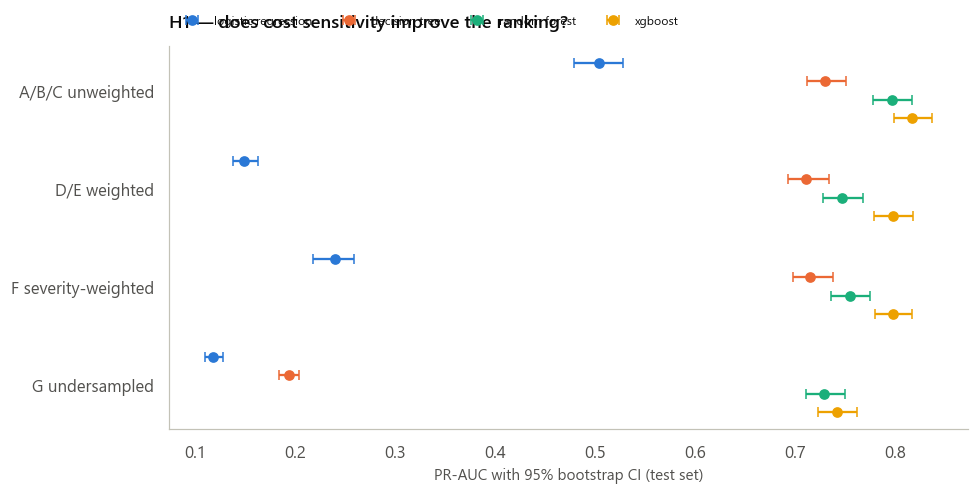

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.6))

order = ["A/B/C unweighted", "D/E weighted", "F severity-weighted", "G undersampled"]
offsets = np.linspace(-0.28, 0.28, len(C.LEARNERS))

for offset, learner in zip(offsets, C.LEARNERS):
    sub = h1[h1["learner"] == learner].set_index("label").reindex(order)
    positions = np.arange(len(order)) + offset
    ax.errorbar(sub["pr_auc"], positions,
                xerr=[sub["pr_auc"] - sub["ci_low"], sub["ci_high"] - sub["pr_auc"]],
                fmt="o", markersize=6, capsize=3, linewidth=1.5,
                color=viz.LEARNER_COLORS[learner], label=learner.replace("_", " "))

ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.invert_yaxis()
ax.set(title="H1: does cost sensitivity improve the ranking?",
       xlabel="PR-AUC with 95% bootstrap CI (test set)")
# Bottom-left is occupied by the undersampled row's markers, so the
# legend goes above the axes rather than on top of the data.
ax.legend(fontsize=8, loc="lower left", bbox_to_anchor=(0, 1.02), ncol=4)
viz.despine(ax)
ax.grid(axis="y", visible=False)

fig.tight_layout()
viz.save_figure(fig, "04_h1_pr_auc")
plt.show()

## The mechanism

Johnson & Khoshgoftaar's account of *why* weighting fails is specific and testable: it shifts predicted probabilities toward 0.5 without improving the ranking. The histogram below tests that directly rather than assuming it  if the weighted distribution has moved right while PR-AUC stayed flat, the mechanism is confirmed on mobile money.

This also has a practical consequence. The prototype exposes a 0–100 risk score, and a score is only meaningful if calibrated. A weighted model that inflates every probability produces a risk score that reads high for transactions that are not.

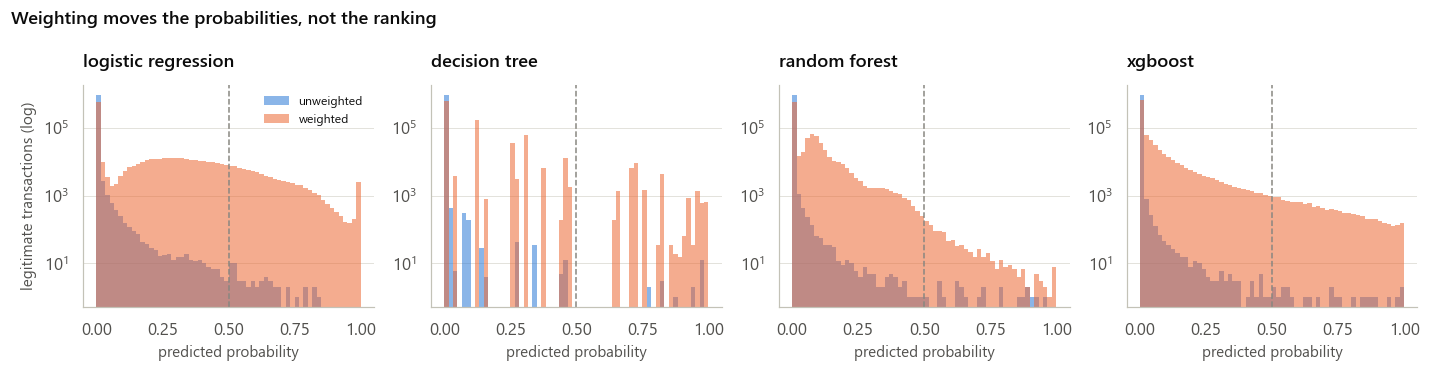

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))

for ax, learner in zip(axes, C.LEARNERS):
    for variant, label in (("unweighted", "unweighted"), ("weighted", "weighted")):
        cached = E.load_predictions(learner, variant, "test", seed, tag=RUNG)
        legit = cached.loc[cached["y_true"] == 0, "score"]
        ax.hist(legit, bins=60, range=(0, 1), alpha=0.55, log=True,
                color=viz.CATEGORICAL[0] if variant == "unweighted" else viz.CATEGORICAL[1],
                label=label)

    ax.axvline(0.5, color=viz.INK["muted"], linestyle="--", linewidth=1)
    ax.set(title=learner.replace("_", " "), xlabel="predicted probability")
    viz.despine(ax)

axes[0].set_ylabel("legitimate transactions (log)")
axes[0].legend(fontsize=8)
fig.suptitle("Weighting moves the probabilities, not the ranking",
             x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
viz.save_figure(fig, "04_probability_shift")
plt.show()

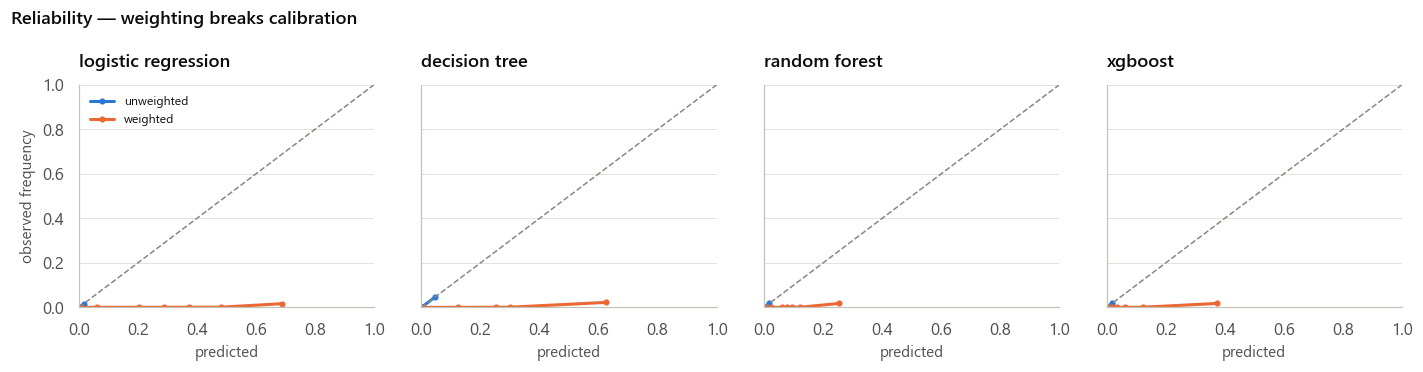

In [8]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
for ax, learner in zip(axes, C.LEARNERS):
    for variant, colour in (("unweighted", viz.CATEGORICAL[0]),
                            ("weighted", viz.CATEGORICAL[1])):
        cached = E.load_predictions(learner, variant, "test", seed, tag=RUNG)
        observed, predicted = calibration_curve(cached["y_true"], cached["score"],
                                                n_bins=15, strategy="quantile")
        ax.plot(predicted, observed, marker="o", markersize=3, color=colour,
                label=variant)

    ax.plot([0, 1], [0, 1], color=viz.INK["muted"], linestyle="--", linewidth=1)
    ax.set(title=learner.replace("_", " "), xlabel="predicted", xlim=(0, 1), ylim=(0, 1))
    viz.despine(ax)

axes[0].set_ylabel("observed frequency")
axes[0].legend(fontsize=8)
fig.suptitle("Reliability: weighting breaks calibration", x=0.005, ha="left",
             fontsize=12, fontweight="semibold")
fig.tight_layout()
viz.save_figure(fig, "04_calibration_comparison")
plt.show()

## What actually reduces risk

PR-AUC asks whether the ranking improved. This asks the operational question: which configuration leaves the least risk on the table, and at what alert volume?

A configuration that shaves NER while tripling the review queue is not an improvement anyone can staff  which is exactly the trade Aleksandrova & Armianova found the ROC-optimal threshold making.

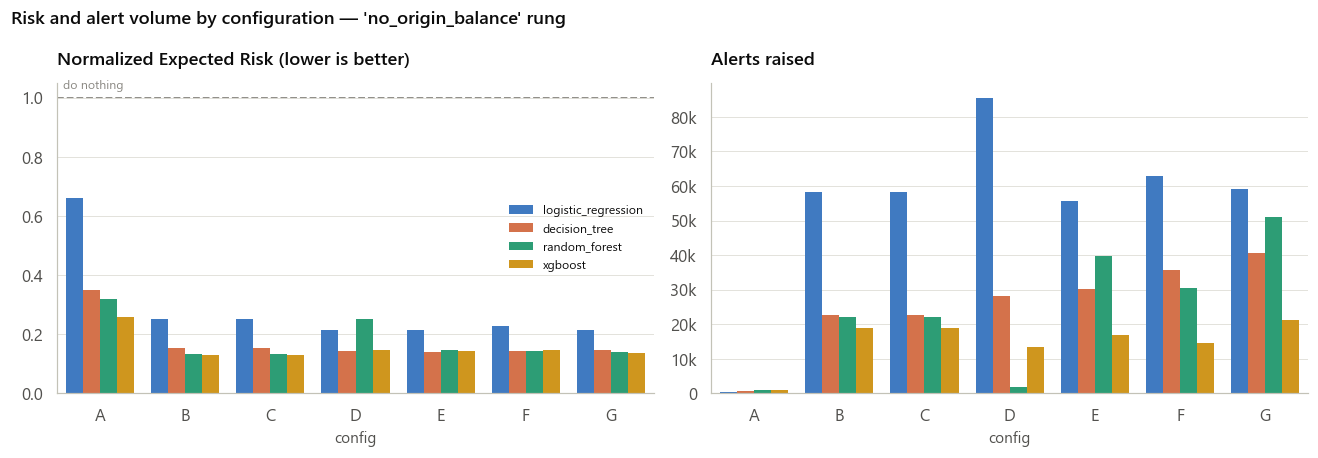

In [9]:
fig, (ax_ner, ax_alerts) = plt.subplots(1, 2, figsize=(12, 4.2))
config_order = list("ABCDEFG")

for ax, metric, title in ((ax_ner, "ner", "Normalized Expected Risk (lower is better)"),
                          (ax_alerts, "n_flagged", "Alerts raised")):
    sns.barplot(test, x="config", y=metric, hue="learner", order=config_order,
                palette=viz.LEARNER_COLORS, ax=ax, legend=(ax is ax_ner))
    ax.set(title=title, xlabel="config", ylabel="")
    viz.despine(ax)

ax_alerts.yaxis.set_major_formatter(viz.compact_number)
viz.annotate_reference(ax_ner, 1.0, "do nothing", axis="y", side="left")
ax_ner.legend(fontsize=8, title="")

fig.suptitle(f"Risk and alert volume by configuration  '{RUNG}' rung",
             x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
viz.save_figure(fig, "04_ner_by_config")
plt.show()

In [10]:
best = test.loc[test.groupby("learner")["ner"].idxmin(),
                ["learner", "config", "level", "threshold_rule", "ner",
                 "recall", "precision", "n_flagged"]]
E.save_results(best.to_dict("records"), "04_best_config_per_learner")

print("Lowest-risk configuration per learner:\n")
print(best.round(4).to_string(index=False))
print("\nNext: 05_lokanan_replication.ipynb: reproducing the leaked protocol,")
print("then scoring that same model on a clean natural-prevalence test set.")

Lowest-risk configuration per learner:

            learner config              level threshold_rule    ner  recall  precision  n_flagged
      decision_tree      E algorithm+decision    ner_optimal 0.1408  0.8896     0.0365      30058
logistic_regression      G               data    ner_optimal 0.2126  0.8482     0.0177      59034
      random_forest      B           decision         youden 0.1324  0.8896     0.0497      22033
            xgboost      B           decision         youden 0.1314  0.8872     0.0582      18776

Next: 05_lokanan_replication.ipynb  reproducing the leaked protocol,
then scoring that same model on a clean natural-prevalence test set.
